In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("BlackFriday.csv")

In [3]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,2.0,NaN,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,15.0,16.0,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,15.0,NaN,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,NaN,NaN,7172


# Check column types

In [4]:
# Numeric - User-ID,Occupation,Stay_In_Current_City_Years,Purchase
# Categorical - Gender,Age,City_Category,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
# Mixed - Product-ID

In [11]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64

In [12]:
# As category 2 and 3 have so many null values, we would remove these columns 

In [13]:
del df["Product_Category_2"]
del df["Product_Category_3"]

In [14]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,7172


In [15]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Purchase                      0
dtype: int64

# Univariate Analysis

## User-ID

In [5]:
df["User_ID"].describe()

count    5.375770e+05
mean     1.002992e+06
std      1.714393e+03
min      1.000001e+06
25%      1.001495e+06
50%      1.003031e+06
75%      1.004417e+06
max      1.006040e+06
Name: User_ID, dtype: float64

In [7]:
df["User_ID"].value_counts()

User_ID
1001680    1025
1004277     978
1001941     898
1001181     861
1000889     822
           ... 
1002111       6
1004991       6
1005810       6
1005391       6
1000708       5
Name: count, Length: 5891, dtype: int64

# Occupation

- Occupation is almost normally distributed

In [8]:
df["Occupation"].describe()

count    537577.00000
mean          8.08271
std           6.52412
min           0.00000
25%           2.00000
50%           7.00000
75%          14.00000
max          20.00000
Name: Occupation, dtype: float64

In [9]:
df["Occupation"].value_counts()

Occupation
4     70862
0     68120
7     57806
1     45971
17    39090
20    32910
12    30423
14    26712
2     25845
16    24790
6     19822
3     17366
10    12623
5     11985
15    11812
11    11338
19     8352
13     7548
18     6525
9      6153
8      1524
Name: count, dtype: int64

In [10]:
df["Occupation"].skew()

np.float64(0.39973275078717607)

# Gender
- No null values
- 75 percent of the customers were MALE and remaining 25 percent were FEMALE
- No outliers
- although men are more in number, the mean spending by men and women are almost the same for each purchase  -> men and women are spending almost the same per purchase 
- 77 percent of money is spent by men and 23 percent of money is spent by women 

In [16]:
df["Gender"]

0         F
1         F
2         F
3         F
4         M
         ..
537572    M
537573    M
537574    M
537575    M
537576    M
Name: Gender, Length: 537577, dtype: object

In [18]:
df["Gender"].nunique()

2

In [19]:
df["Gender"].value_counts()

Gender
M    405380
F    132197
Name: count, dtype: int64

In [20]:
# More men have purchased things during balck friday sale

<Axes: xlabel='Gender'>

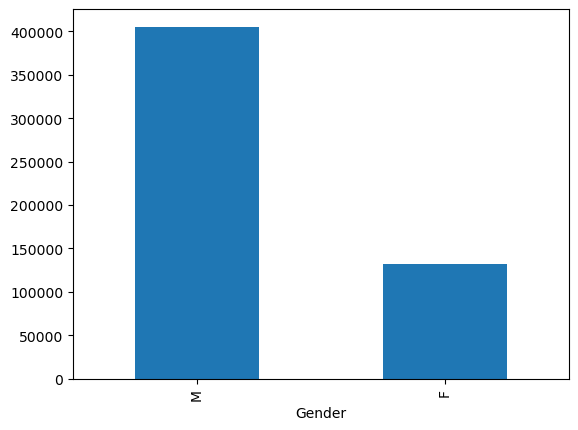

In [21]:
df['Gender'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

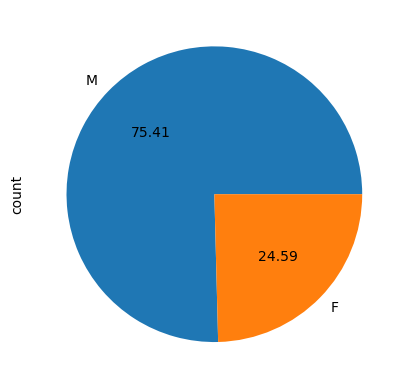

In [22]:
df["Gender"].value_counts().plot(kind = "pie",autopct = "%.2f")

In [23]:
# 75 percent of the customers were MALE 
# remaining 25 percent were FEMALE

In [24]:
df["Gender"].isnull().sum()

np.int64(0)

<Axes: >

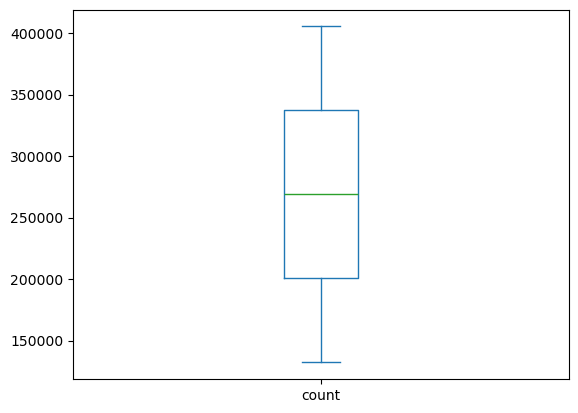

In [25]:
df["Gender"].value_counts().plot(kind = "box")

In [26]:
df.groupby("Gender")["Purchase"].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,132197.0,8809.761349,4721.440055,185.0,5459.0,7929.0,11436.0,23959.0
M,405380.0,9504.771713,5051.057256,185.0,5901.0,8112.0,12542.0,23961.0


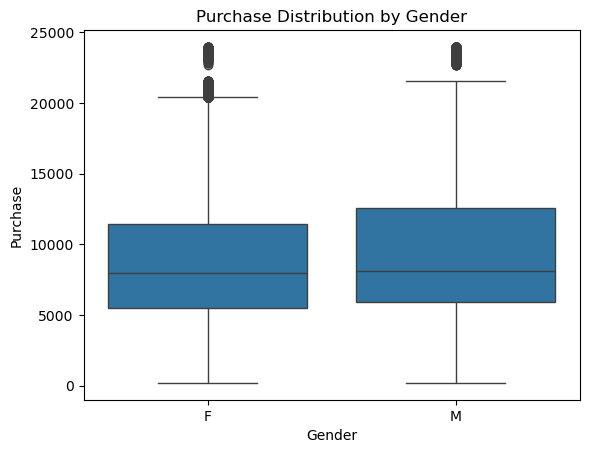

In [27]:
sns.boxplot(x="Gender", y="Purchase", data=df)
plt.title("Purchase Distribution by Gender")
plt.show()

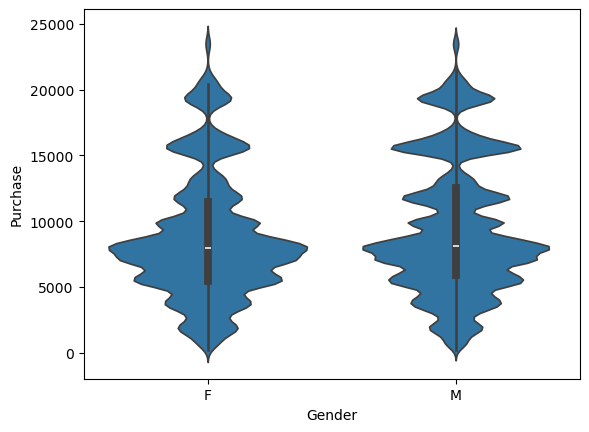

In [28]:
sns.violinplot(x="Gender", y="Purchase", data=df)
plt.show()


In [30]:
Purchases = df.groupby("Gender")["Purchase"].sum()

In [34]:
Purchases = Purchases.astype(float)

In [32]:
pd.options.display.float_format = '{:,.2f}'.format

In [35]:
Purchases * 100 / Purchases.sum()

Gender
F   23.21
M   76.79
Name: Purchase, dtype: float64

# Age
- It is a right skewed distribution
- Highest number of customers(40 percent) are between 26-35 and least(3 percent) are between 0-17
- 40 percent of total money is spent by customers between 26-35 and least(2.64 percent) is spent by customers between 0-17
- Customers between age 51-55 spent the most per product 
- No null values
- No outliers 

In [37]:
df["Age"]

0          0-17
1          0-17
2          0-17
3          0-17
4           55+
          ...  
537572    36-45
537573    36-45
537574    36-45
537575    36-45
537576    36-45
Name: Age, Length: 537577, dtype: object

In [39]:
df["Age"].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [48]:
df["Age"].value_counts() * 100/df["Age"].value_counts().sum()

Age
26-35   39.94
36-45   20.00
18-25   18.16
46-50    8.28
51-55    7.00
55+      3.89
0-17     2.74
Name: count, dtype: float64

In [49]:
df["Age"].isnull().sum()

np.int64(0)

<Axes: ylabel='Frequency'>

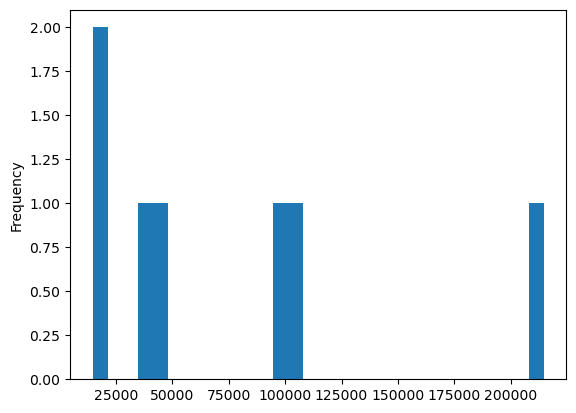

In [41]:
df["Age"].value_counts().plot(kind = "hist",bins = 30)

<Axes: ylabel='Density'>

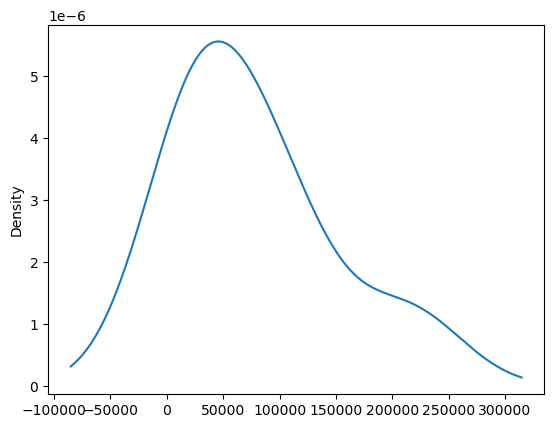

In [42]:
df["Age"].value_counts().plot(kind = "kde")

In [44]:
df["Age"].value_counts().skew()

np.float64(1.4241797693853415)

<Axes: xlabel='Age'>

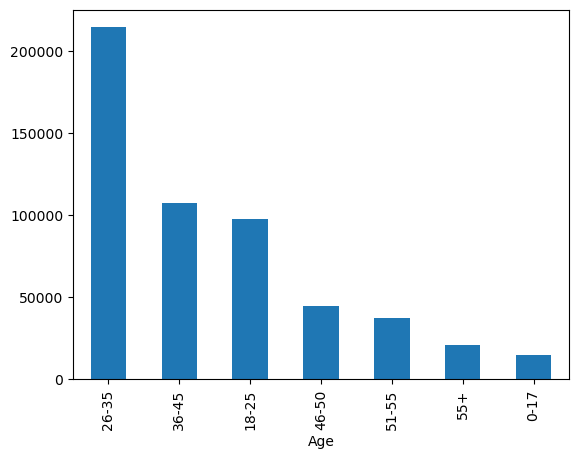

In [45]:
df["Age"].value_counts().plot(kind = "bar")

<Axes: ylabel='Purchase'>

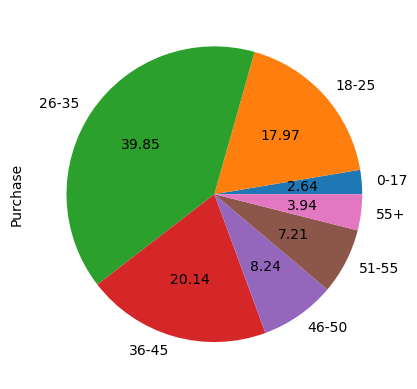

In [47]:
df.groupby("Age")["Purchase"].sum().plot(kind = "pie",autopct = "%.2f")

<Axes: ylabel='Purchase'>

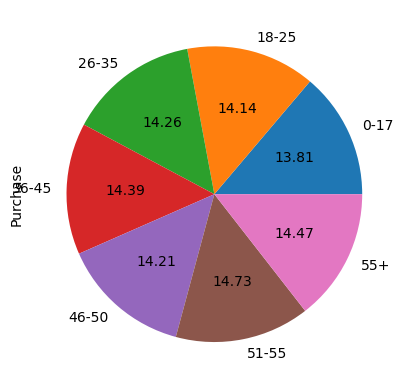

In [78]:
df.groupby("Age")["Purchase"].mean().plot(kind = "pie",autopct = "%.2f")

<Axes: xlabel='Age'>

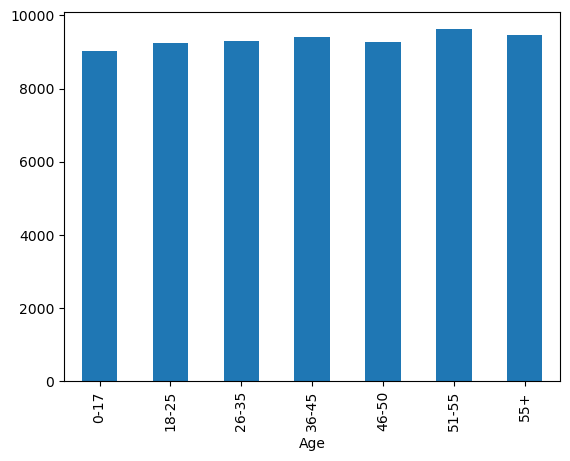

In [79]:
df.groupby("Age")["Purchase"].mean().plot(kind = "bar")

# Martial Status 
- There are 60 percent of unmarried customers and 40 percent of married customers
- 60 percent of purchases are done by unmarried customers and rest 40 percent is done by married customers
- No null values

In [54]:
df["Marital_Status"]

0         0
1         0
2         0
3         0
4         0
         ..
537572    0
537573    0
537574    0
537575    0
537576    0
Name: Marital_Status, Length: 537577, dtype: int64

In [55]:
df["Marital_Status"].value_counts()

Marital_Status
0    317817
1    219760
Name: count, dtype: int64

In [56]:
df["Marital_Status"].value_counts() * 100 / df["Marital_Status"].value_counts().sum()

Marital_Status
0   59.12
1   40.88
Name: count, dtype: float64

In [75]:
df["Marital_Status"].skew()

np.float64(0.3710367513397353)

<Axes: ylabel='Density'>

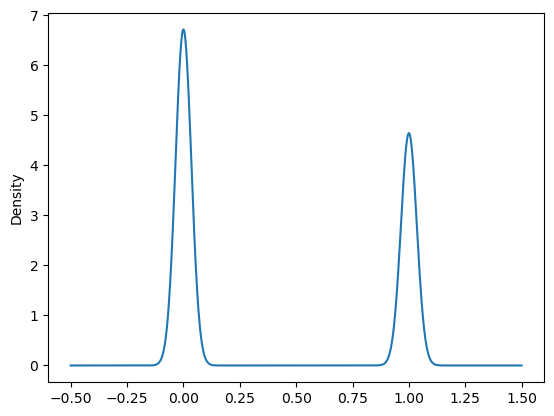

In [76]:
df["Marital_Status"].plot(kind = "kde")

<Axes: ylabel='count'>

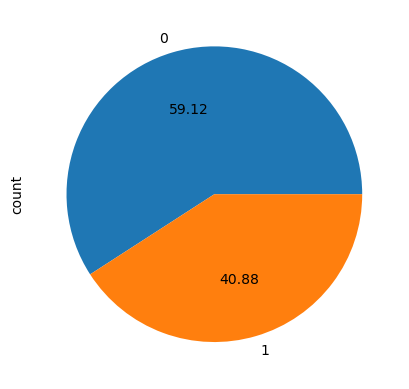

In [58]:
df["Marital_Status"].value_counts().plot(kind = "pie",autopct = "%.2f")

In [64]:
data = df.groupby("Marital_Status")["Purchase"].sum().astype(float)

In [71]:
data

Marital_Status
0   2,966,289,500.00
1   2,051,378,878.00
Name: Purchase, dtype: float64

In [73]:
data * 100 / data.sum()

Marital_Status
0   59.12
1   40.88
Name: Purchase, dtype: float64

<Axes: xlabel='Marital_Status'>

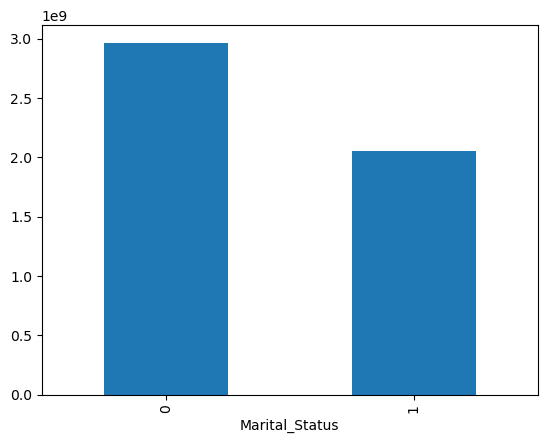

In [62]:
data.plot(kind = "bar")

In [77]:
df["Marital_Status"].isnull().sum()

np.int64(0)

#  Multivariate Analysis 

# Age and Gender 
- Male customers are greater in number than female ones irrespective of the age category 

In [93]:
pd.crosstab(df["Age"],df["Gender"])

Gender,F,M
Age,,
0-17,4953,9754
18-25,24057,73577
26-35,49348,165342
36-45,26420,81079
46-50,12856,31670
51-55,9634,27984
55+,4929,15974


In [90]:
pd.crosstab(df["Age"],df["Gender"], normalize="index" )* 100

Gender,F,M
Age,,
0-17,33.68,66.32
18-25,24.64,75.36
26-35,22.99,77.01
36-45,24.58,75.42
46-50,28.87,71.13
51-55,25.61,74.39
55+,23.58,76.42


<Axes: xlabel='Age'>

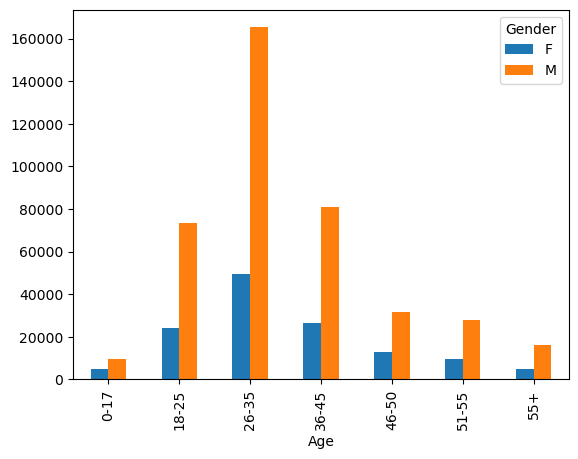

In [96]:
pd.crosstab(df["Age"],df["Gender"]).plot(kind = "bar")

# Gender and Martial Status
- almost all the married men and women came together for shopping (approx 40 percent)
- Unmarried customers are more than married customers 

In [99]:
pd.crosstab(df["Gender"],df["Marital_Status"])

Marital_Status,0,1
Gender,,
F,76974,55223
M,240843,164537


In [100]:
pd.crosstab(df["Gender"],df["Marital_Status"],normalize = "index") * 100

Marital_Status,0,1
Gender,,
F,58.23,41.77
M,59.41,40.59


<Axes: xlabel='Gender'>

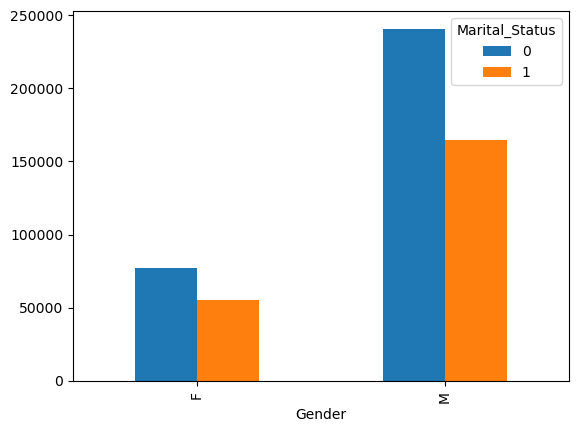

In [101]:
pd.crosstab(df["Gender"],df["Marital_Status"]).plot(kind = "bar")

# Occupation and Product Category

In [106]:
pd.crosstab(df["Product_Category_1"],df["Occupation"])

Occupation,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
Product_Category_1,,,,,,,,,,,,,,,,,,,,,
1,17382,10109,5635,3913,18996,3617,4526,15824,506,1114,...,2617,9110,1532,7390,3314,6389,12583,1742,2065,6770
2,2929,1880,1083,661,3001,581,810,2468,97,279,...,471,1403,354,1093,570,1102,1940,305,325,1438
3,2589,1515,942,606,3260,443,727,1574,67,355,...,340,1165,149,776,431,742,1479,160,262,1228
4,1456,949,501,394,1683,252,430,1087,39,250,...,217,565,122,466,225,437,792,124,224,695
5,18703,12850,7443,5239,20200,3250,5580,15356,367,2127,...,3344,7918,1947,7549,3108,6698,9574,1738,2352,9659
6,2528,1719,1019,644,2622,376,722,2280,45,191,...,506,1077,262,1159,425,929,1367,273,335,1397
7,554,369,226,134,443,35,143,322,5,15,...,83,181,47,154,81,192,170,34,60,378
8,13856,11736,6127,3803,13628,1904,4698,12423,263,1290,...,2545,5647,2205,5428,2441,5267,6704,1100,1642,7635
9,48,26,11,13,51,8,16,38,1,2,...,9,30,2,22,14,22,51,2,7,21


In [107]:
pd.crosstab(df["Product_Category_1"],df["Occupation"],normalize = "index") * 100

Occupation,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
Product_Category_1,,,,,,,,,,,,,,,,,,,,,
1,12.56,7.31,4.07,2.83,13.73,2.61,3.27,11.44,0.37,0.81,...,1.89,6.58,1.11,5.34,2.40,4.62,9.09,1.26,1.49,4.89
2,12.46,8.00,4.61,2.81,12.77,2.47,3.45,10.50,0.41,1.19,...,2.00,5.97,1.51,4.65,2.43,4.69,8.26,1.30,1.38,6.12
3,13.04,7.63,4.75,3.05,16.42,2.23,3.66,7.93,0.34,1.79,...,1.71,5.87,0.75,3.91,2.17,3.74,7.45,0.81,1.32,6.19
4,12.59,8.20,4.33,3.41,14.55,2.18,3.72,9.40,0.34,2.16,...,1.88,4.88,1.05,4.03,1.95,3.78,6.85,1.07,1.94,6.01
5,12.59,8.65,5.01,3.53,13.59,2.19,3.76,10.33,0.25,1.43,...,2.25,5.33,1.31,5.08,2.09,4.51,6.44,1.17,1.58,6.50
6,12.54,8.53,5.05,3.19,13.00,1.86,3.58,11.31,0.22,0.95,...,2.51,5.34,1.30,5.75,2.11,4.61,6.78,1.35,1.66,6.93
7,15.10,10.06,6.16,3.65,12.08,0.95,3.90,8.78,0.14,0.41,...,2.26,4.93,1.28,4.20,2.21,5.23,4.63,0.93,1.64,10.31
8,12.36,10.47,5.46,3.39,12.15,1.70,4.19,11.08,0.23,1.15,...,2.27,5.04,1.97,4.84,2.18,4.70,5.98,0.98,1.46,6.81
9,11.88,6.44,2.72,3.22,12.62,1.98,3.96,9.41,0.25,0.50,...,2.23,7.43,0.50,5.45,3.47,5.45,12.62,0.50,1.73,5.20


In [114]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,7172
